In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_parquet("20240701.parquet")
print(df.shape)
print(df.columns)

(434742, 37)
Index(['DST_IP', 'DST_IP_SUBNET', 'DST_IP_VERSION', 'DST_ASN', 'DST_COUNTRY',
       'DST_PORT', 'PROTOCOL', 'TIME_FIRST', 'TIME_LAST', 'DURATION',
       'FLOW_END_REASON', 'BYTES', 'BYTES_REV', 'PACKETS', 'PACKETS_REV',
       'QUIC_VERSION', 'QUIC_CLIENT_VERSION', 'QUIC_TOKEN_LENGTH',
       'QUIC_MULTIPLEXED', 'QUIC_ZERO_RTT', 'QUIC_OCCID', 'QUIC_OSCID',
       'QUIC_SCID', 'QUIC_RETRY_SCID', 'QUIC_SNI', 'QUIC_USER_AGENT',
       'QUIC_TLS_EXT_LEN', 'QUIC_TLS_EXT_TYPE', 'QUIC_PACKETS', 'PPI',
       'PPI_LEN', 'PPI_DURATION', 'PPI_ROUNDTRIPS', 'PHIST_SRC_SIZES',
       'PHIST_DST_SIZES', 'PHIST_SRC_IPT', 'PHIST_DST_IPT'],
      dtype='object')


In [42]:
def map_traffic_type(sni):
    if pd.isna(sni):
        return "Other"
    
    sni = sni.lower()
    
    
    # 🎬 Video Streaming
    if any(x in sni for x in ["youtube", "googlevideo", "netflix", "primevideo", "hotstar"]):
        return "Video Streaming"
    
    # 📱 Messaging / Realtime
    elif any(x in sni for x in ["whatsapp", "telegram", "messenger"]):
        return "Messaging"
    
    # 🎮 Gaming (basic detection)
    elif any(x in sni for x in ["epicgames", "steam", "riotgames", "pubg"]):
        return "Gaming"
    
    # 🌐 Web Browsing
    elif any(x in sni for x in ["google", "facebook", "instagram", "wikipedia"]):
        return "Web Browsing"
    
    # 📦 CDN / Downloads
    elif any(x in sni for x in ["cloudflare", "akamai", "cdn"]):
        return "Download/CDN"
    
    else:
        return "Other"

df["Traffic Type"] = df["QUIC_SNI"].apply(map_traffic_type)

In [20]:
t=0
for i in df["Traffic Type"]:
    if i=="Gaming":
        print(df["QUIC_SNI"][t])
    t=t+1

stats.steaminventoryhelper.com
api.steaminventoryhelper.com
steamdb.info


NameError: name 'sni' is not defined

In [56]:
df_display = df[[
    "DURATION",
    "PACKETS",
    "PACKETS_REV",
    "BYTES",
    "BYTES_REV",
    "DST_COUNTRY",
    "QUIC_SNI",
    "Traffic Type",
    "PPI_LEN",
    "DST_ASN"
]].copy()

In [31]:
df_display["Total Packets"] = df_display["PACKETS"] + df_display["PACKETS_REV"]
df_display["Total Bytes"] = df_display["BYTES"] + df_display["BYTES_REV"]

In [32]:
df_display = df_display.drop(
    ["PACKETS", "PACKETS_REV", "BYTES", "BYTES_REV"], axis=1
)

df_display.rename(columns={
    "DURATION": "Duration (s)",
    "DST_COUNTRY": "Country",
    "QUIC_SNI": "Domain"
}, inplace=True)

In [57]:
from IPython.display import display
display(df_display)

,DURATION,PACKETS,PACKETS_REV,BYTES,BYTES_REV,DST_COUNTRY,QUIC_SNI,Traffic Type,PPI_LEN,DST_ASN
0,8.463623,47,44,24480,20249,US,play.google.com,Web Browsing,30,15169
1,0.193551,10,9,4245,2686,ZZ,discordapp.com,Other,19,13335
2,0.075073,8,8,2404,3527,US,beacons.gcp.gvt2.com,Other,16,15169
3,0.235215,13,11,3486,6801,US,youtubei.googleapis.com,Video Streaming,24,15169
4,25.456515,22,23,7366,14880,US,www.recaptcha.net,Other,30,15169
...,...,...,...,...,...,...,...,...,...,...
434737,1.048031,15,16,5356,8424,IE,rr4---sn-2gb7snez.googlevideo.com,Video Streaming,30,15169
434738,0.110865,24,28,7089,24102,US,cdn.ampproject.org,Download/CDN,30,15169
434739,0.941010,9,22,3118,14215,CZ,scontent-prg1-1.cdninstagram.com,Web Browsing,30,32934
434740,13.506115,24,19,13756,4542,US,gew4-spclient.spotify.com,Other,30,15169


In [47]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1200)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

In [35]:

# -----------------------------
# 1. Basic Safety (avoid divide by zero)
# -----------------------------
eps = 1e-6

# -----------------------------
# 2. Rate Features
# -----------------------------
df["packet_rate"] = df["PACKETS"] / (df["DURATION"] + eps)
df["packet_rate_rev"] = df["PACKETS_REV"] / (df["DURATION"] + eps)

df["byte_rate"] = df["BYTES"] / (df["DURATION"] + eps)
df["byte_rate_rev"] = df["BYTES_REV"] / (df["DURATION"] + eps)

# -----------------------------
# 3. Direction & Balance Features
# -----------------------------
df["total_packets"] = df["PACKETS"] + df["PACKETS_REV"]
df["total_bytes"] = df["BYTES"] + df["BYTES_REV"]

df["direction_ratio"] = df["PACKETS"] / (df["total_packets"] + eps)

df["packet_ratio"] = df["PACKETS"] / (df["PACKETS_REV"] + eps)
df["byte_ratio"] = df["BYTES"] / (df["BYTES_REV"] + eps)

# -----------------------------
# 4. Latency Approximation (RTT)
# -----------------------------
df["avg_rtt"] = df["DURATION"] / (df["PPI_ROUNDTRIPS"] + eps)

# -----------------------------
# 5. Helper: Safe parsing (for hist columns)
# -----------------------------
import ast

def parse_if_needed(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return x

# -----------------------------
# 6. Jitter (from IPT histograms)
# -----------------------------
def compute_jitter(x):
    x = parse_if_needed(x)
    if isinstance(x, (list, np.ndarray)) and len(x) > 1:
        return np.std(x)
    return 0

df["src_jitter"] = df["PHIST_SRC_IPT"].apply(compute_jitter)
df["dst_jitter"] = df["PHIST_DST_IPT"].apply(compute_jitter)

# -----------------------------
# 7. Avg Inter-packet time (optional but good)
# -----------------------------
def compute_mean(x):
    x = parse_if_needed(x)
    if isinstance(x, (list, np.ndarray)) and len(x) > 0:
        return np.mean(x)
    return 0

df["src_avg_ipt"] = df["PHIST_SRC_IPT"].apply(compute_mean)
df["dst_avg_ipt"] = df["PHIST_DST_IPT"].apply(compute_mean)

# -----------------------------
# 8. Burstiness (advanced QoS)
# -----------------------------
df["packet_burst"] = df["PACKETS"] / (df["PPI_DURATION"] + eps)




In [61]:
cols = [
    "DURATION",
    "total_packets",
    "total_bytes",

    "packet_rate",
    "packet_rate_rev",
    "byte_rate",
    "byte_rate_rev",

    "direction_ratio",
    "packet_ratio",
    "byte_ratio",

    "avg_rtt",

    "src_jitter",
    "dst_jitter",

    "src_avg_ipt",
    "dst_avg_ipt",

    "packet_burst",

    "PPI_LEN",
    "PPI_DURATION",
    "PPI_ROUNDTRIPS"
  
]

df_clean = df[cols]

df_clean.head(10)

,DURATION,total_packets,total_bytes,packet_rate,packet_rate_rev,byte_rate,byte_rate_rev,direction_ratio,packet_ratio,byte_ratio,avg_rtt,src_jitter,dst_jitter,src_avg_ipt,dst_avg_ipt,packet_burst,PPI_LEN,PPI_DURATION,PPI_ROUNDTRIPS
0,8.463623,91,44729,10.751884,5.198719,5284.846354,2392.473957,1.208949,1.068182,1.208949,1.209089,9.496710,7.983381,5.750,5.375,179.388628,30,0.262,7
1,0.193551,19,6931,98.160270,46.499132,35807.833190,13877.407622,1.580417,1.111111,1.580417,0.064517,2.260393,1.658312,1.125,1.000,51.813203,19,0.193,3
2,0.075073,16,5931,213.097505,106.561526,78992.581543,46980.312758,0.681599,1.000000,0.681599,0.015015,1.690969,1.964529,0.875,0.875,106.665244,16,0.075,5
3,0.235215,24,10287,102.029971,46.765526,43732.596450,28913.849398,0.512572,1.181818,0.512572,0.039202,3.605551,2.222049,1.500,1.250,55.318914,24,0.235,6
4,25.456515,45,22246,1.767720,0.903501,873.882040,584.526178,0.495027,0.956522,0.495027,3.182064,5.146297,4.789311,2.625,2.750,215.684160,30,0.102,8
5,0.096007,25,12201,260.370559,114.573786,127071.247800,33268.060995,2.819975,1.272727,2.819975,0.019201,3.237958,2.586020,1.625,1.250,145.831814,25,0.096,5
6,0.197473,33,15348,167.102991,96.215198,77718.082063,43084.152851,0.803949,0.736842,0.803949,0.028210,3.568526,4.841229,1.625,2.250,88.607034,30,0.158,7
7,2.061455,215,188450,104.294761,73.734293,91415.570965,87716.157900,0.042179,0.414474,0.042179,0.412291,19.376210,48.055794,7.750,18.875,1188.656818,30,0.053,5
8,51.909388,211,38449,4.064775,1.907169,740.694392,228.397988,2.242999,1.131313,2.242999,12.977344,25.915427,21.305809,13.875,12.250,1333.317461,30,0.084,4
9,0.182189,29,15101,159.166626,76.842856,82881.903852,54289.478017,0.526741,1.071428,0.526741,0.026027,3.561952,3.237958,1.750,1.625,81.966765,29,0.183,7


In [38]:
df["total_packets"] = df["PACKETS"] + df["PACKETS_REV"]
df["total_bytes"] = df["BYTES"] + df["BYTES_REV"]

df["packet_rate"] = df["total_packets"] / (df["DURATION"] + 1e-5)
df["byte_rate"] = df["total_bytes"] / (df["DURATION"] + 1e-5)

df["direction_ratio"] = df["BYTES"] / (df["BYTES_REV"] + 1e-5)

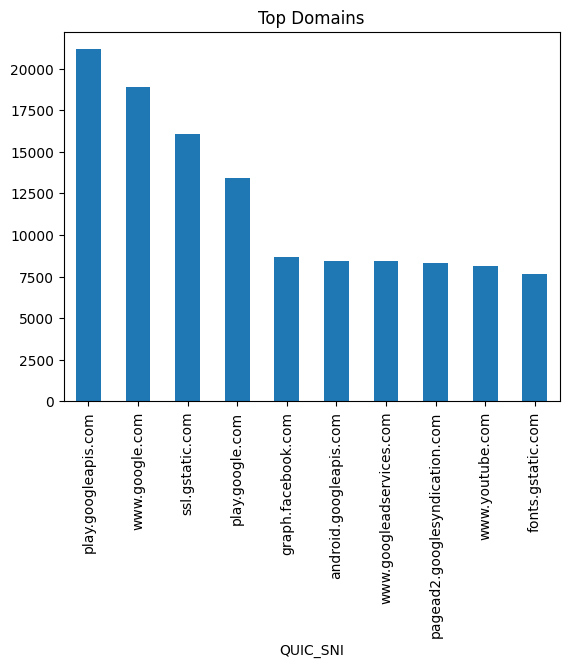

In [39]:
df["QUIC_SNI"].value_counts().head(10).plot(kind="bar")
plt.title("Top Domains")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

features = [
    "DURATION",
    "total_packets",
    "total_bytes",

    "packet_rate",
    "packet_rate_rev",
    "byte_rate",
    "byte_rate_rev",

    "direction_ratio",
    "packet_ratio",
    "byte_ratio",

    "avg_rtt",

    "src_jitter",
    "dst_jitter",

    "src_avg_ipt",
    "dst_avg_ipt",

    "packet_burst",

    "PPI_LEN",
    "PPI_DURATION",
    "PPI_ROUNDTRIPS"
]

X = df[features].fillna(0)
y = df["Traffic Type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [52]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.8050926405134045


In [59]:
import joblib

# Save model
joblib.dump(model, "qos_model.pkl")

['qos_model.pkl']

In [53]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

   Download/CDN       0.71      0.38      0.49      2561
      Messaging       0.70      0.06      0.11       113
          Other       0.82      0.71      0.76     28690
Video Streaming       0.73      0.45      0.56      5034
   Web Browsing       0.80      0.92      0.86     50551

       accuracy                           0.81     86949
      macro avg       0.75      0.50      0.56     86949
   weighted avg       0.80      0.81      0.80     86949



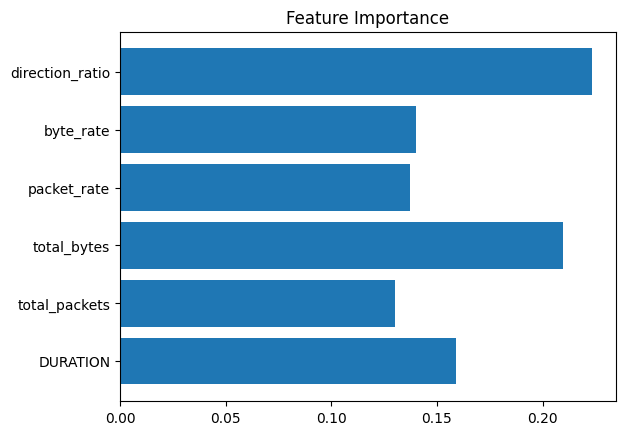

In [18]:
importances = model.feature_importances_

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [46]:
def qos_policy(label):
    if label == "streaming":
        return "high_throughput"
    elif label == "web":
        return "best_effort"
    else:
        return "default"

df["qos"] = df["label"].apply(qos_policy)

In [47]:
def ppi_to_timeseries(ppi):
    times, dirs, sizes = ppi
    
    # cumulative time (x-axis)
    t = np.cumsum(times)
    
    return t, sizes, dirs

In [48]:
import numpy as np

def ppi_to_rate(ppi):
    times, dirs, sizes = ppi
    
    times = np.array(times)
    sizes = np.array(sizes)
    
    t = np.cumsum(times)
    
    if len(t) < 2:
        return None, None
    
    dt = np.diff(t)
    rate = sizes[1:] / (dt + 1e-5)
    
    return t[1:], rate

In [49]:
def resample_series(t, y, length=100):
    if t is None or len(t) < 2:
        return None
    
    t_norm = (t - t.min()) / (t.max() - t.min() + 1e-5)
    t_new = np.linspace(0, 1, length)
    
    y_new = np.interp(t_new, t_norm, y)
    
    return y_new

In [26]:
services = ["streaming", "web", "other"]

patterns = {}

for service in services:
    subset = df[df["label"] == service].sample(100, random_state=42)
    
    all_series = []
    
    for ppi in subset["PPI"]:
        t, rate = ppi_to_rate(ppi)
        y = resample_series(t, rate)
        
        if y is not None:
            all_series.append(y)
    
    if len(all_series) > 0:
        patterns[service] = np.mean(all_series, axis=0)

In [27]:
def map_service(sni):
    if pd.isna(sni):
        return "unknown"
    
    sni = sni.lower()
    
    if "youtube" in sni or "googlevideo" in sni:
        return "YouTube"
    elif "facebook" in sni or "fbcdn" in sni:
        return "Facebook"
    elif "instagram" in sni:
        return "Instagram"
    elif "whatsapp" in sni:
        return "WhatsApp"
    elif "netflix" in sni:
        return "Netflix"
    elif "google" in sni:
        return "Google"
    elif "cloudflare" in sni:
        return "Cloudflare"
    else:
        return "Other"

df["service"] = df["QUIC_SNI"].apply(map_service)

In [28]:
df["service"].value_counts().head(10)

service
Google        229985
Other         150084
YouTube        25147
Facebook       20129
Instagram       7745
Cloudflare      1207
WhatsApp         445
Name: count, dtype: int64

In [29]:
top_services = df["service"].value_counts().head(5).index.tolist()

In [30]:
import numpy as np

def ppi_to_rate(ppi):
    times, dirs, sizes = ppi
    
    times = np.array(times)
    sizes = np.array(sizes)
    
    t = np.cumsum(times)
    
    if len(t) < 2:
        return None
    
    dt = np.diff(t)
    rate = sizes[1:] / (dt + 1e-5)
    
    return t[1:], rate

In [31]:
def resample_series(t, y, length=100):
    t_norm = (t - t.min()) / (t.max() - t.min() + 1e-5)
    t_new = np.linspace(0, 1, length)
    
    return np.interp(t_new, t_norm, y)

In [32]:
patterns = {}

for service in top_services:
    subset = df[df["service"] == service].sample(100, random_state=42)
    
    series_list = []
    
    for ppi in subset["PPI"]:
        result = ppi_to_rate(ppi)
        if result is None:
            continue
        
        t, rate = result
        
        if len(rate) < 5:
            continue
        
        y = resample_series(t, rate)
        series_list.append(y)
    
    if len(series_list) > 0:
        patterns[service] = np.mean(series_list, axis=0)

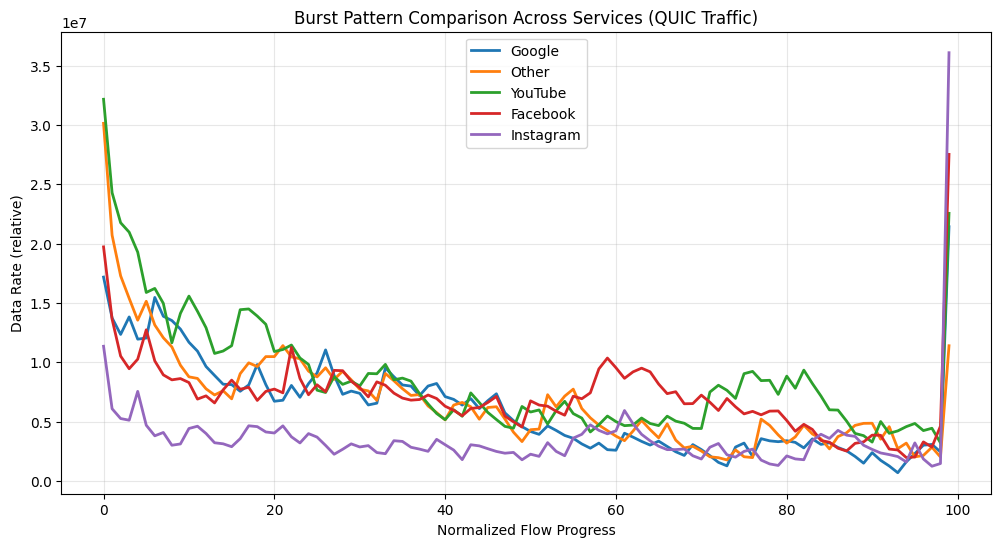

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for service, pattern in patterns.items():
    plt.plot(pattern, linewidth=2, label=service)

plt.title("Burst Pattern Comparison Across Services (QUIC Traffic)")
plt.xlabel("Normalized Flow Progress")
plt.ylabel("Data Rate (relative)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [35]:
def map_service(sni):
    if pd.isna(sni):
        return "unknown"
    
    sni = sni.lower()
    
    if "youtube" in sni or "googlevideo" in sni:
        return "YouTube"
    elif "facebook" in sni or "fbcdn" in sni:
        return "Facebook"
    elif "instagram" in sni:
        return "Instagram"
    elif "whatsapp" in sni:
        return "WhatsApp"
    elif "netflix" in sni:
        return "Netflix"
    elif "google" in sni:
        return "Google"
    else:
        return "Other"

df["service"] = df["QUIC_SNI"].apply(map_service)

In [36]:
top_services = df["service"].value_counts().head(6).index
df_top = df[df["service"].isin(top_services)]

<Figure size 1000x600 with 0 Axes>

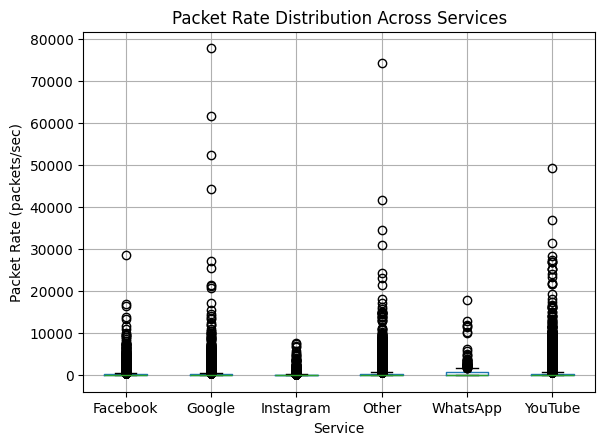

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df_top.boxplot(column="packet_rate", by="service")

plt.title("Packet Rate Distribution Across Services")
plt.suptitle("")
plt.xlabel("Service")
plt.ylabel("Packet Rate (packets/sec)")

plt.show()

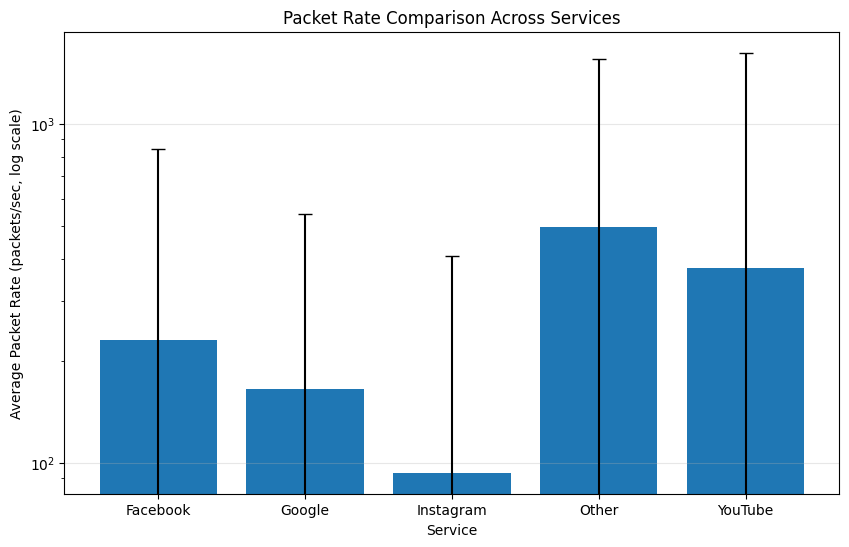

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- Feature ----
df["total_packets"] = df["PACKETS"] + df["PACKETS_REV"]
df["packet_rate"] = df["total_packets"] / (df["DURATION"] + 1e-5)

# ---- Service Mapping ----
def map_service(sni):
    if pd.isna(sni):
        return "Other"
    
    sni = sni.lower()
    
    if "youtube" in sni or "googlevideo" in sni:
        return "YouTube"
    elif "facebook" in sni or "fbcdn" in sni:
        return "Facebook"
    elif "instagram" in sni:
        return "Instagram"
    elif "whatsapp" in sni:
        return "WhatsApp"
    elif "netflix" in sni:
        return "Netflix"
    elif "google" in sni:
        return "Google"
    else:
        return "Other"

df["service"] = df["QUIC_SNI"].apply(map_service)

# ---- Select top services ----
top_services = df["service"].value_counts().head(5).index
df_plot = df[df["service"].isin(top_services)]

# ---- Compute stats ----
stats = df_plot.groupby("service")["packet_rate"].agg(["mean", "std"])

# ---- Plot ----
plt.figure(figsize=(10,6))

plt.bar(
    stats.index,
    stats["mean"],
    yerr=stats["std"],   # error bars
    capsize=5
)

plt.yscale("log")   # IMPORTANT
plt.xlabel("Service")
plt.ylabel("Average Packet Rate (packets/sec, log scale)")
plt.title("Packet Rate Comparison Across Services")
plt.grid(axis='y', alpha=0.3)

plt.show()

In [41]:
from sklearn.model_selection import train_test_split

features = [
    "DURATION",
    "total_packets",
    "total_bytes",
    "packet_rate",
    "byte_rate",
    "direction_ratio"
]

X = df[features].fillna(0)
y = df["service"]   # or "label"

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

print("LR Accuracy:", model_lr.score(X_test, y_test))

/Users/kavyajain/Desktop/quic_project/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LR Accuracy: 0.5383155642963117


In [43]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

print("RF Accuracy:", model_rf.score(X_test, y_test))

RF Accuracy: 0.7503824080782988


In [54]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier()
model_gb.fit(X_train, y_train)

print("GB Accuracy:", model_gb.score(X_test, y_test))

GB Accuracy: 0.6696224223395324


In [44]:
from sklearn.neural_network import MLPClassifier

model_mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300)
model_mlp.fit(X_train, y_train)

print("MLP Accuracy:", model_mlp.score(X_test, y_test))

MLP Accuracy: 0.5284247087373057


In [56]:
models = {
    "Logistic Regression": model_lr,
    "Random Forest": model_rf,
    "Gradient Boosting": model_gb,
    "MLP": model_mlp
}

for name, model in models.items():
    print(name, ":", model.score(X_test, y_test))

Logistic Regression : 0.5383155642963117
Random Forest : 0.7503824080782988
Gradient Boosting : 0.6696224223395324
MLP : 0.5284247087373057


In [57]:
from sklearn.metrics import classification_report

y_pred = model_rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Facebook       0.65      0.32      0.43      4045
      Google       0.75      0.88      0.81     45946
   Instagram       0.62      0.37      0.47      1606
       Other       0.77      0.68      0.72     30218
    WhatsApp       0.63      0.12      0.21        96
     YouTube       0.65      0.42      0.51      5038

    accuracy                           0.75     86949
   macro avg       0.68      0.47      0.53     86949
weighted avg       0.75      0.75      0.74     86949



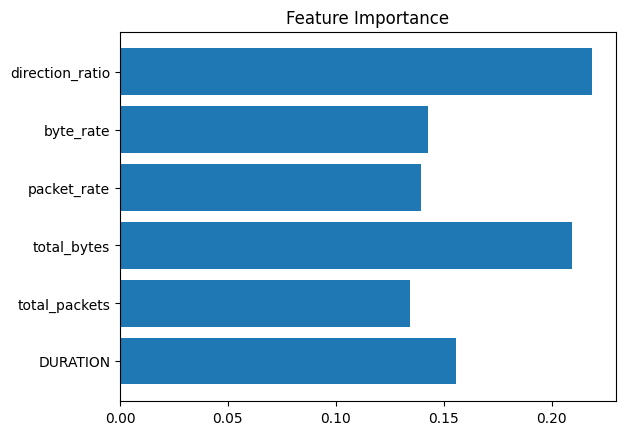

In [58]:
import matplotlib.pyplot as plt

importances = model_rf.feature_importances_

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [59]:
def qos_policy(service):
    if service in ["YouTube", "Netflix"]:
        return "high_throughput"
    elif service in ["WhatsApp"]:
        return "low_latency"
    else:
        return "best_effort"

pred = model_rf.predict(X_test)

qos = [qos_policy(p) for p in pred]